# Escalabilidade Computacional e a Maldição da Dimensão no Problema das Marginais Quânticas (QMP)

Este notebook realiza um benchmark empírico e analítico completo para demonstrar o fenômeno da **Maldição da Dimensão** no **Problema das Marginais Quânticas (Quantum Marginal Problem - QMP)** resolvido via Otimização Convexa / Programação Semidefinida (SDP).

## 1. Fundamentação Teórica da Maldição da Dimensão no QMP

O espaço de Hilbert $\mathcal{H}$ de um sistema quântico composto por $N$ subsistemas locais de dimensão $d$ possui dimensão que escala **exponencialmente** com o número de subsistemas:

$$\dim(\mathcal{H}) = d^N$$

Consequentemente, o operador densidade global $\rho \in \mathcal{L}(\mathcal{H})$ é representado por uma matriz Hermitiana complexa de ordem $d^N \times d^N$, exigindo $d^{2N}$ parâmetros complexos (ou $d^{2N}-1$ variáveis reais independentes) para sua especificação completa.

Ao formular o QMP como uma Programação Semidefinida (SDP):

$$\text{Encontrar } \rho \ge 0 \quad \text{sujeito a} \quad \mathcal{A}(\rho) = b$$

a complexidade de armazenamento da matriz e o número de restrições de consistência marginal $\mathcal{A}(\rho) = b$ explodem, tornando a solução numérica por solvers de ponto interior (como o **CLARABEL**) intratável para dimensões moderadas.


## 2. Configuração do Ambiente de Execução e Bibliotecas

Importação das funções de suporte (`funcoes_fundamentais.py`), manipuladores numéricos (`numpy`, `pandas`) e bibliotecas de plotagem (`matplotlib`).


In [2]:
from funcoes_fundamentais import *
import pandas as pd
import numpy as np


### 2.1 Instalação de Pacotes do Ambiente

Instalação dos solvers e bibliotecas quânticas (`sdp`, `spacecore==0.4.2`).


In [3]:
# Instalação das dependências necessárias no ambiente
# Nota: spacecore==0.4.2 é recomendado para total compatibilidade com sdplab==0.0.1
! pip install -q numpy matplotlib scipy "spacecore==0.4.2" sdplab cvxpy clarabel scs jax

### 2.2 Configuração de Módulos Auxiliares

Importações complementares para medir tempos de execução (`time`) e otimização de memória.


In [4]:
from __future__ import annotations

import sys
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
# Bibliotecas SpaceCore e SDPLab para Programação Semidefinida 
import spacecore
from spacecore import Context, DenseVectorSpace, HermitianSpace, NumpyOps
import sdplab
from sdplab import DenseConstraintOp, SDPProblem
from sdplab.solvers import run_cvxpy_solver

np.set_printoptions(precision=4, suppress=True)

from funcoes_fundamentais import zero, one, ketbra, verifica_densidade, verify_marginals, base_hermitiana, ghz, partial_trace, tensor, embed_operator, solve_qmp, build_qmp_sdp, parse_subsystem_key, basis
print(f"Versão SDPLab:    {sdplab.__version__}")
print(f"Versão SpaceCore: {spacecore.__version__}")

Versão SDPLab:    0.0.1
Versão SpaceCore: 0.4.2


## 3. Exemplo Concreto: Cadeia 1D de $N = 4$ Qubits com Vizinhos Próximos

Neste primeiro teste prático, construímos uma cadeia unidimensional de 4 qubits com $d=2$ (dimensão total $\dim(\mathcal{H}) = 2^4 = 16$). As restrições do SDP são dadas pelas marginais reduzidas de pares vizinhos $\rho_{12}, \rho_{23}, \rho_{34}$.

Medimos o tempo de montagem do SDP $t_{\text{build}}$ e o tempo de solução $t_{\text{solve}}$ pelo solver **CLARABEL**.


In [6]:

import time

N_qubits = 4
dims_4q = [2] * N_qubits

print(f"--- Construindo Instância com N = {N_qubits} Qubits ---")
print(f"Dimensão do Espaço de Hilbert: d = 2^{N_qubits} = {2**N_qubits}")
print(f"Dimensão do Espaço de Operadores: d^2 = 4^{N_qubits} = {4**N_qubits} parâmetros reais")

# 1. Construção do estado global de referência: |GHZ_4> = (|0000> + |1111>) / sqrt(2)
psi_0_4 = tensor(*([zero] * N_qubits))
psi_1_4 = tensor(*([one] * N_qubits))
psi_ghz_4 = (psi_0_4 + psi_1_4) / np.sqrt(2.0)
rho_ghz_4 = ketbra(psi_ghz_4)

print(f"Formato da matriz densidade global rho_4q: {rho_ghz_4.shape} ({rho_ghz_4.size} entradas)")

# 2. Extração das marginais bipartidas de primeiros vizinhos: (0, 1), (1, 2) e (2, 3)
marginals_4q = {
    (0, 1): partial_trace(rho_ghz_4, keep=[0, 1], dims=dims_4q),
    (1, 2): partial_trace(rho_ghz_4, keep=[1, 2], dims=dims_4q),
    (2, 3): partial_trace(rho_ghz_4, keep=[2, 3], dims=dims_4q),
}

print(f"\nMarginais prescritas para subsistemas de primeiros vizinhos ({len(marginals_4q)} pares):")
for pair, mat in marginals_4q.items():
    print(f"  Par {pair}: matriz {mat.shape[0]}x{mat.shape[1]}, Tr(omega) = {np.trace(mat).real:.4f}")

# 3. Construção do problema SDP via SDPLab
t0_build_4q = time.perf_counter()
sdp_4q, M_4q, b_4q = build_qmp_sdp(marginals_4q, dims=dims_4q)
t_build_4q = time.perf_counter() - t0_build_4q

print(f"\nSDP montado:")
print(f"  Dimensão do domínio Hermitiano: {sdp_4q.dom.n}x{sdp_4q.dom.n}")
print(f"  Número total de restrições afins escalares m: {len(b_4q)}")
print(f"    - 1 restrição de normalização: Tr(rho) = 1")
print(f"    - {len(marginals_4q)} * 16 = {len(marginals_4q) * 16} restrições de projeção nas marginais locais")
print(f"  Tempo de montagem das matrizes globais: {t_build_4q:.4f} s")

# 4. Resolução com o solver CLARABEL
t0_solve_4q = time.perf_counter()
res_4q = solve_qmp(sdp_4q, solver="CLARABEL")
t_solve_4q = time.perf_counter() - t0_solve_4q

print(f"\nResultado do Solver SDP:")
print(f"  Status: {res_4q['status']}")
print(f"  Problema Factível: {res_4q['is_feasible']}")
print(f"  Tempo de resolução do solver: {t_solve_4q:.4f} s")

# 5. Auditoria rigorosa da solução obtida
verif_4q = verify_marginals(res_4q["rho"], marginals_4q, dims=dims_4q)
print(f"\nAuditoria Física do Estado Reconstruído:")
print(f"  Erro de Hermiticidade: ||rho - rho^dag||_F = {verif_4q['hermitian_error']:.2e}")
print(f"  Traço Tr(rho):          {verif_4q['trace'].real:.12f} (Erro: {verif_4q['trace_error']:.2e})")
print(f"  Menor autovalor lambda_min: {verif_4q['min_eigenvalue']:.2e} -> rho >= 0: {verif_4q['is_psd']}")
print(f"  Pureza Tr(rho^2):       {verif_4q['purity']:.4f}")
print("  Resíduos por marginal:")
for k, err in verif_4q["marginal_errors"].items():
    print(f"    Marginal {k}: Erro Frobenius = {err['frobenius_error']:.2e}, Max Abs = {err['max_abs_error']:.2e}")

--- Construindo Instância com N = 4 Qubits ---
Dimensão do Espaço de Hilbert: d = 2^4 = 16
Dimensão do Espaço de Operadores: d^2 = 4^4 = 256 parâmetros reais
Formato da matriz densidade global rho_4q: (16, 16) (256 entradas)

Marginais prescritas para subsistemas de primeiros vizinhos (3 pares):
  Par (0, 1): matriz 4x4, Tr(omega) = 1.0000
  Par (1, 2): matriz 4x4, Tr(omega) = 1.0000
  Par (2, 3): matriz 4x4, Tr(omega) = 1.0000

SDP montado:
  Dimensão do domínio Hermitiano: 16x16
  Número total de restrições afins escalares m: 49
    - 1 restrição de normalização: Tr(rho) = 1
    - 3 * 16 = 48 restrições de projeção nas marginais locais
  Tempo de montagem das matrizes globais: 0.0034 s

Resultado do Solver SDP:
  Status: optimal
  Problema Factível: True
  Tempo de resolução do solver: 0.2178 s

Auditoria Física do Estado Reconstruído:
  Erro de Hermiticidade: ||rho - rho^dag||_F = 0.00e+00
  Traço Tr(rho):          1.000000000000 (Erro: 4.44e-16)
  Menor autovalor lambda_min: -1.05e

## 4. Benchmark Sistemático 1: Escalabilidade no Número de Qubits ($N = 3, 4, 5, 6$)

Realizamos um escaneamento empírico aumentando o número de qubits de $N=3$ a $N=6$.

| $N$ (Qubits) | $\dim(\mathcal{H}) = 2^N$ | Elementos de $\rho$ ($2^{2N}$) | Estrutura de Marginais |
| :---: | :---: | :---: | :---: |
| 3 | 8 | 64 | Pares (12, 23) |
| 4 | 16 | 256 | Pares (12, 23, 34) |
| 5 | 32 | 1.024 | Pares (12, 23, 34, 45) |
| 6 | 64 | 4.096 | Pares (12, 23, 34, 45, 56) |


In [7]:

qubits_range = [3, 4, 5, 6]
benchmark_results = []

print("Executando benchmark de escalabilidade do QMP (N = 3 a 6 qubits)...\n")

for n_q in qubits_range:
    dims_n = [2] * n_q
    
    # 1. Estado GHZ de n_q qubits
    psi_0_n = tensor(*([zero] * n_q))
    psi_1_n = tensor(*([one] * n_q))
    psi_ghz_n = (psi_0_n + psi_1_n) / np.sqrt(2.0)
    rho_ghz_n = ketbra(psi_ghz_n)

    # 2. Marginais de primeiros vizinhos: (0, 1), (1, 2), ..., (n_q-2, n_q-1)
    marginals_n = {}
    for i in range(n_q - 1):
        marginals_n[(i, i + 1)] = partial_trace(rho_ghz_n, keep=[i, i + 1], dims=dims_n)

    # 3. Montagem do problema SDP
    t0_b = time.perf_counter()
    sdp_n, M_n, b_n = build_qmp_sdp(marginals_n, dims=dims_n)
    t_build = time.perf_counter() - t0_b

    # 4. Resolução com o solver SDP CLARABEL
    t0_s = time.perf_counter()
    res_n = solve_qmp(sdp_n, solver="CLARABEL")
    t_solve = time.perf_counter() - t0_s

    dim_H = 2**n_q
    dim_rho_entries = dim_H**2
    num_constraints = len(b_n)

    benchmark_results.append({
        "N": n_q,
        "dim_H": dim_H,
        "dim_rho": f"{dim_H}x{dim_H}",
        "entries": dim_rho_entries,
        "constraints": num_constraints,
        "t_build": t_build,
        "t_solve": t_solve,
        "status": res_n["status"],
        "feasible": res_n["is_feasible"],
    })
    del psi_0_n, psi_1_n, psi_ghz_n
    del rho_ghz_n, marginals_n
    del sdp_n, M_n, b_n, res_n

    
    gc.collect()

# Exibição da tabela comparativa
print("=" * 95)
print(f"{'N':>3} | {'dim(H)':>8} | {'Matriz rho':>12} | {'Param. Reais':>13} | {'Restrições m':>13} | {'t_build (s)':>12} | {'t_solve (s)':>12} | {'Status':>12}")
print("=" * 95)
for row in benchmark_results:
    print(f"{row['N']:3d} | {row['dim_H']:8d} | {row['dim_rho']:>12s} | {row['entries']:13d} | {row['constraints']:13d} | {row['t_build']:12.4f} | {row['t_solve']:12.4f} | {row['status']:>12s}")
print("=" * 95)



Executando benchmark de escalabilidade do QMP (N = 3 a 6 qubits)...

  N |   dim(H) |   Matriz rho |  Param. Reais |  Restrições m |  t_build (s) |  t_solve (s) |       Status
  3 |        8 |          8x8 |            64 |            33 |       0.0008 |       0.0393 |      optimal
  4 |       16 |        16x16 |           256 |            49 |       0.0022 |       0.1058 |      optimal
  5 |       32 |        32x32 |          1024 |            65 |       0.0030 |       1.3041 |      optimal
  6 |       64 |        64x64 |          4096 |            81 |       0.0086 |      19.6712 | optimal_inaccurate


/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/sdplab/solvers/_cvxpy.py:138: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=solver, verbose=verbose, *args, **kwargs)


## 5. Visualização Gráfica do Crescimento Exponencial com $N$

Geramos gráficos com escala logarítmica no eixo $Y$ para ilustrar:
1. **Painel Esquerdo**: O crescimento exponencial da dimensão do espaço de Hilbert $\dim(\mathcal{H})$ e do número de variáveis da matriz densidade $\dim(\rho)$.
2. **Painel Direito**: O tempo de resolução $t_{\text{solve}}$ do solver SDP e um ajuste exponencial da forma $O(e^{\alpha N})$.


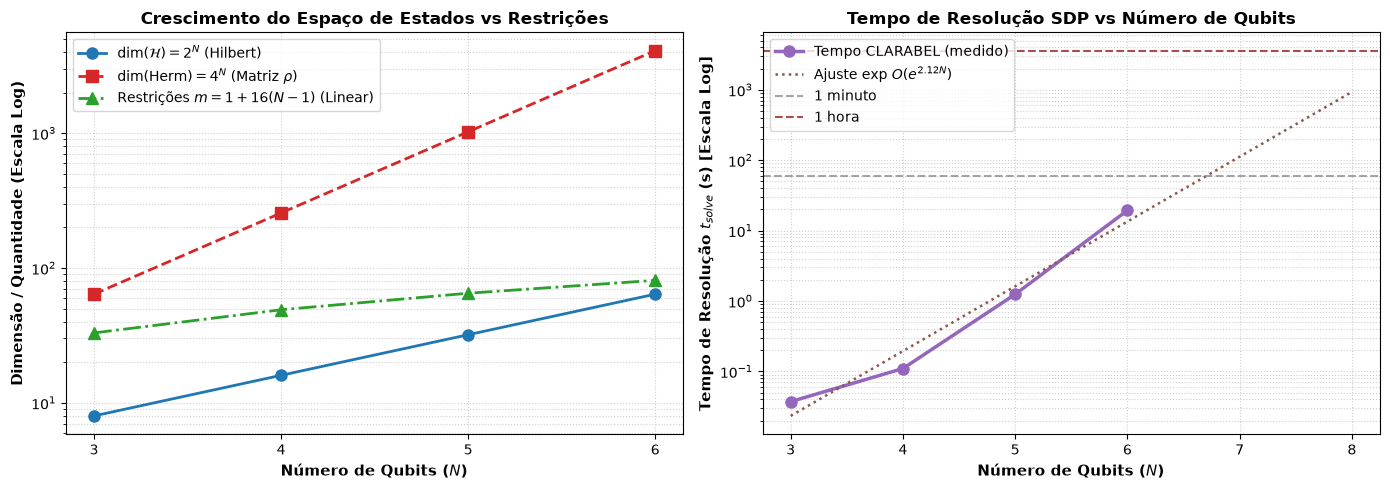

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

N_vals = [d["N"] for d in benchmark_results]
dim_H_vals = [d["dim_H"] for d in benchmark_results]
entries_vals = [d["entries"] for d in benchmark_results]
t_solve_vals = [d["t_solve"] for d in benchmark_results]
m_vals = [d["constraints"] for d in benchmark_results]

# Subplot 1: Crescimento do Espaço de Estados vs Restrições
ax1.semilogy(N_vals, dim_H_vals, "o-", color="#1f77b4", linewidth=2, markersize=8, label=r"$\dim(\mathcal{H}) = 2^N$ (Hilbert)")
ax1.semilogy(N_vals, entries_vals, "s--", color="#d62728", linewidth=2, markersize=8, label=r"$\dim(\mathrm{Herm}) = 4^N$ (Matriz $\rho$)")
ax1.plot(N_vals, m_vals, "^-.", color="#2ca02c", linewidth=2, markersize=8, label=r"Restrições $m = 1 + 16(N-1)$ (Linear)")
ax1.set_xlabel("Número de Qubits ($N$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Dimensão / Quantidade (Escala Log)", fontsize=11, fontweight="bold")
ax1.set_title("Crescimento do Espaço de Estados vs Restrições", fontsize=12, fontweight="bold")
ax1.set_xticks(N_vals)
ax1.grid(True, which="both", linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", fontsize=10)

# Subplot 2: Tempo de Resolução SDP vs N com Extrapolação
ax2.semilogy(N_vals, t_solve_vals, "o-", color="#9467bd", linewidth=2.5, markersize=8, label="Tempo CLARABEL (medido)")

# Ajuste exponencial dos tempos medidos para ilustrar a barreira computacional
p = np.polyfit(N_vals, np.log(t_solve_vals), 1)
N_extrap = np.array([3, 4, 5, 6, 7, 8])
t_extrap = np.exp(p[1] + p[0] * N_extrap)
ax2.semilogy(N_extrap, t_extrap, ":", color="#8c564b", linewidth=1.8, label=f"Ajuste exp $O(e^{{{p[0]:.2f}N}})$")

ax2.axhline(60, color="gray", linestyle="--", alpha=0.7, label="1 minuto")
ax2.axhline(3600, color="darkred", linestyle="--", alpha=0.7, label="1 hora")

ax2.set_xlabel("Número de Qubits ($N$)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Tempo de Resolução $t_{solve}$ (s) [Escala Log]", fontsize=11, fontweight="bold")
ax2.set_title("Tempo de Resolução SDP vs Número de Qubits", fontsize=12, fontweight="bold")
ax2.set_xticks(N_extrap)
ax2.grid(True, which="both", linestyle=":", alpha=0.6)
ax2.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

## 6. Benchmark Sistemático 2: Escalabilidade na Dimensão Local $d$ ($d = 2, 3, 4, 5, 6$)

Fixamos $N=3$ subsistemas e aumentamos a dimensão local $d$ (qubits $d=2$, qutrits $d=3$, ququarts $d=4$, etc.).

A dimensão do espaço de Hilbert escala como $\dim(\mathcal{H}) = d^3$, e o número de entradas da matriz densidade global é $\dim(\rho) = d^6$.
Para $d=6$, a matriz densidade global $\rho_{ABC}$ possui dimensão $216 \times 216$, totalizando $46.656$ entradas complexas.


In [19]:

dims_range = [2,3,4,5]

benchmark_results_d = []

print("Executando benchmark de escalabilidade do QMP")
print("(3 subsistemas, dimensão local d variável)...\n")

for d in dims_range:

    # Dimensões dos três subsistemas
    dims_d = [d, d, d]

    # --------------------------------------------------------------------------
    # 1. Estado GHZ generalizado
    #
    # |GHZ_d> = 1/sqrt(d) sum_k |k,k,k>
    # --------------------------------------------------------------------------

    psi_ghz_d = 0

    for k in range(d):

        ket_k = basis(d, k)

        psi_ghz_d += tensor(ket_k, ket_k, ket_k)

    psi_ghz_d = psi_ghz_d / np.sqrt(d)

    rho_ghz_d = ketbra(psi_ghz_d)

    # --------------------------------------------------------------------------
    # 2. Marginais de dois subsistemas
    #
    # AB, AC e BC
    # --------------------------------------------------------------------------

    marginals_d = {}

    marginals_d[(0, 1)] = partial_trace(
        rho_ghz_d,
        keep=[0, 1],
        dims=dims_d
    )

    marginals_d[(0, 2)] = partial_trace(
        rho_ghz_d,
        keep=[0, 2],
        dims=dims_d
    )

    marginals_d[(1, 2)] = partial_trace(
        rho_ghz_d,
        keep=[1, 2],
        dims=dims_d
    )

    # --------------------------------------------------------------------------
    # 3. Montagem do problema SDP
    # --------------------------------------------------------------------------

    t0_b = time.perf_counter()

    sdp_d, M_d, b_d = build_qmp_sdp(
        marginals_d,
        dims=dims_d
    )

    t_build = time.perf_counter() - t0_b

    # --------------------------------------------------------------------------
    # 4. Resolução com CLARABEL
    # --------------------------------------------------------------------------

    t0_s = time.perf_counter()

    res_d = solve_qmp(
        sdp_d,
        solver="SCS", verbose=False
    )

    t_solve = time.perf_counter() - t0_s

    # --------------------------------------------------------------------------
    # 5. Informações de escalabilidade
    # --------------------------------------------------------------------------

    dim_H = d**3

    dim_rho_entries = dim_H**2

    num_constraints = len(b_d)

    benchmark_results_d.append({

        "d": d,

        "N": 3,

        "dim_H": dim_H,

        "dim_rho": f"{dim_H}x{dim_H}",

        "entries": dim_rho_entries,

        "constraints": num_constraints,

        "t_build": t_build,

        "t_solve": t_solve,

        "status": res_d["status"],

        "feasible": res_d["is_feasible"],

    })
    del rho_ghz_d, marginals_d
    del sdp_d, M_d, b_d, res_d

    gc.collect()




Executando benchmark de escalabilidade do QMP
(3 subsistemas, dimensão local d variável)...



## 7. Exibição da Tabela Comparativa de Escalabilidade por Dimensão Local

Formatação da tabela consolidada com métricas de tempo de construção, tempo de resolução e número de restrições do SDP.


In [20]:
# ==============================================================================
# Exibição da tabela comparativa
# ==============================================================================

print("=" * 100)

print(
    f"{'d':>3} | "
    f"{'dim(H)':>8} | "
    f"{'Matriz rho':>12} | "
    f"{'Param. Reais':>13} | "
    f"{'Restrições m':>13} | "
    f"{'t_build (s)':>12} | "
    f"{'t_solve (s)':>12} | "
    f"{'Status':>12}"
)

print("=" * 100)

for row in benchmark_results_d:

    print(
        f"{row['d']:3d} | "
        f"{row['dim_H']:8d} | "
        f"{row['dim_rho']:>12s} | "
        f"{row['entries']:13d} | "
        f"{row['constraints']:13d} | "
        f"{row['t_build']:12.4f} | "
        f"{row['t_solve']:12.4f} | "
        f"{row['status']:>12s}"
    )

print("=" * 100)


  d |   dim(H) |   Matriz rho |  Param. Reais |  Restrições m |  t_build (s) |  t_solve (s) |       Status
  2 |        8 |          8x8 |            64 |            49 |       0.0010 |       0.0521 |      optimal
  3 |       27 |        27x27 |           729 |           244 |       0.0050 |       0.2331 |      optimal
  4 |       64 |        64x64 |          4096 |           769 |       0.0441 |       1.3813 |      optimal
  5 |      125 |      125x125 |         15625 |          1876 |       0.3704 |       7.8007 |      optimal


## 8. Visualização Gráfica do Crescimento com a Dimensão Local $d$

Gráficos em escala semi-logarítmica comparando o crescimento das restrições e da dimensão com o tempo real de solução do solver **CLARABEL**, exibindo linhas de referência para 1 minuto e 1 hora de computação.


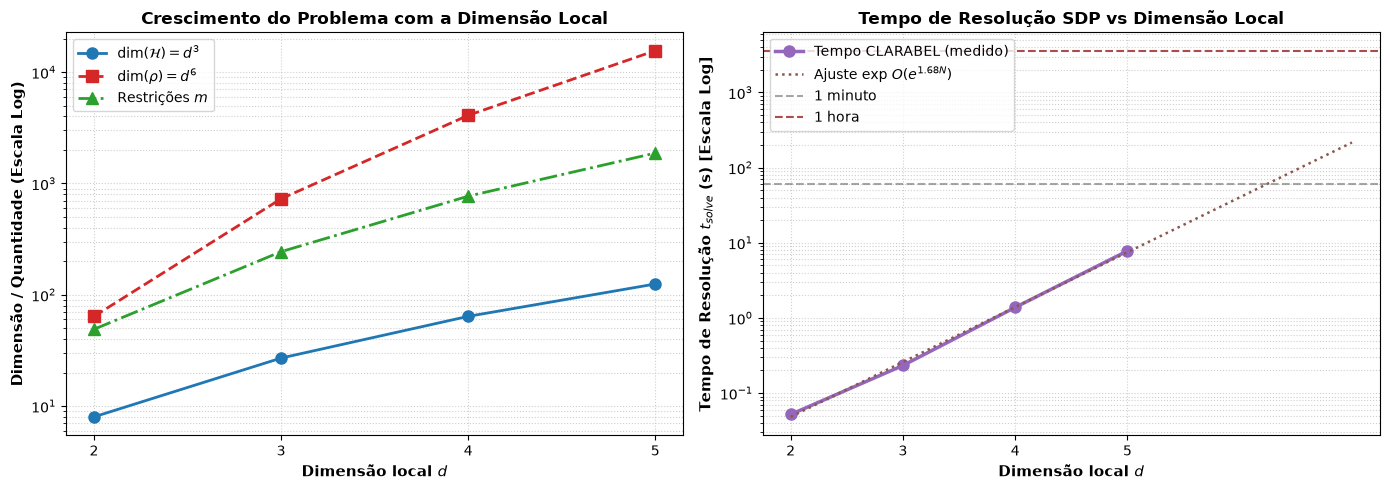

In [22]:
# ==============================================================================
# Visualização Gráfica: Crescimento com a dimensão local
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

d_vals = [x["d"] for x in benchmark_results_d]

dim_H_vals = [x["dim_H"] for x in benchmark_results_d]

entries_vals = [x["entries"] for x in benchmark_results_d]

t_solve_vals = [x["t_solve"] for x in benchmark_results_d]

m_vals = [x["constraints"] for x in benchmark_results_d]


# ------------------------------------------------------------------------------
# Subplot 1: Crescimento dimensional
# ------------------------------------------------------------------------------

ax1.semilogy(
    d_vals,
    dim_H_vals,
    "o-",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
    label=r"$\dim(\mathcal{H}) = d^3$"
)

ax1.semilogy(
    d_vals,
    entries_vals,
    "s--",
    color="#d62728",
    linewidth=2,
    markersize=8,
    label=r"$\dim(\rho) = d^6$"
)

ax1.plot(
    d_vals,
    m_vals,
    "^-.",
    color="#2ca02c",
    linewidth=2,
    markersize=8,
    label="Restrições $m$"
)

ax1.set_xlabel(
    "Dimensão local $d$",
    fontsize=11,
    fontweight="bold"
)

ax1.set_ylabel(
    "Dimensão / Quantidade (Escala Log)",
    fontsize=11,
    fontweight="bold"
)

ax1.set_title(
    "Crescimento do Problema com a Dimensão Local",
    fontsize=12,
    fontweight="bold"
)

ax1.set_xticks(d_vals)

ax1.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.6
)

ax1.legend(
    loc="upper left",
    fontsize=10
)


# ------------------------------------------------------------------------------
# Subplot 2: Tempo de resolução
# ------------------------------------------------------------------------------

ax2.semilogy(
    d_vals,
    t_solve_vals,
    "o-",
    color="#9467bd",
    linewidth=2.5,
    markersize=8,
    label="Tempo CLARABEL (medido)"
)
p_2 = np.polyfit(d_vals, np.log(t_solve_vals), 1)
d_extrap = np.array([2, 3, 4, 5, 6,7])
t_extrap = np.exp(p_2[1] + p_2[0] * d_extrap)
ax2.semilogy(d_extrap, t_extrap, ":", color="#8c564b", linewidth=1.8, label=f"Ajuste exp $O(e^{{{p_2[0]:.2f}N}})$")

ax2.set_xlabel(
    "Dimensão local $d$",
    fontsize=11,
    fontweight="bold"
)

ax2.set_ylabel(
    "Tempo de Resolução $t_{solve}$ (s) [Escala Log]",
    fontsize=11,
    fontweight="bold"
)

ax2.set_title(
    "Tempo de Resolução SDP vs Dimensão Local",
    fontsize=12,
    fontweight="bold"
)

ax2.set_xticks(d_vals)
ax2.axhline(60, color="gray", linestyle="--", alpha=0.7, label="1 minuto")
ax2.axhline(3600, color="darkred", linestyle="--", alpha=0.7, label="1 hora")
ax2.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.6
)

ax2.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

plt.show()